In [78]:
from langchain_groq  import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()
llm  = ChatGroq(model="llama-3.1-8b-instant")


In [79]:
class customer_state(TypedDict):
    question: str
    answer: str
    score: float
    sentiment_of_cust: str

In [80]:
class sent_schema(BaseModel):
    score: float = Field(description="The score of the sentiment out of 10 , 1 very negative to 10 very positive")

structured_llm = llm.with_structured_output(sent_schema)

In [81]:
def find_sentiment(state: customer_state):
    prompt = f" The question is {state['question']}, find its sentiment and give it a score in a range from 1,very bad to 10, very good"

    result = structured_llm.invoke(prompt)
   
    return {'score': result.score}

In [82]:
def check_condition(state: customer_state)-> Literal[ 'positive_sen', 'negative_sen' ]:
    score = state["score"]

    if score > 5:
        return 'positive_sen'
    else:
        return 'negative_sen'

In [83]:
def positive_sen(state: customer_state):
    prompt = f"based on {state['question']} and {state['score']} give a positive response"
    answer = llm.invoke(prompt).content
    state["answer"] = answer
    return {'answer': answer}

In [84]:
def negative_sen(state: customer_state):
    prompt = f"based on {state['question']} and {state['score']} write a apology and explain hows the issue will be solved"
    answer = llm.invoke(prompt).content
    state["answer"] = answer
    return {'answer': answer}

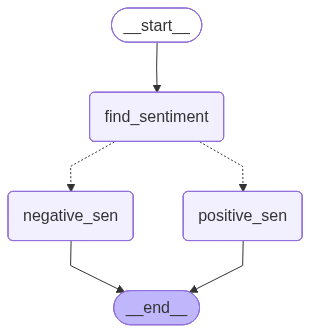

In [85]:
graph = StateGraph(customer_state)
 
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_sen", positive_sen)
graph.add_node("negative_sen", negative_sen)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_condition)
graph.add_edge("positive_sen", END)
graph.add_edge("negative_sen", END)

workflow = graph.compile()
workflow

In [87]:
initial_state = {'question': 'the product was of good quality'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'the product was of good quality', 'answer': "I'm thrilled to hear that the product met your expectations and exceeded them with a 9.0 rating. It's clear that the manufacturer has put a lot of effort into ensuring the quality and performance of their product.\n\nI completely agree that a 9.0 rating is outstanding, and it's a testament to the product's reliability, durability, and overall value. The fact that it's been crafted with high-quality materials and attention to detail is evident in its performance and longevity.\n\nIf you don't mind me asking, what specifically impressed you about the product? Was it a particular feature, its ease of use, or something else entirely? I'm curious to know what made it stand out to you.\n\nIn any case, I'm glad you're happy with your purchase, and I'm confident that you'll continue to enjoy using this product for a long time. Thank you for sharing your positive experience with me!", 'score': 9.0}
